In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../data/data1.csv')

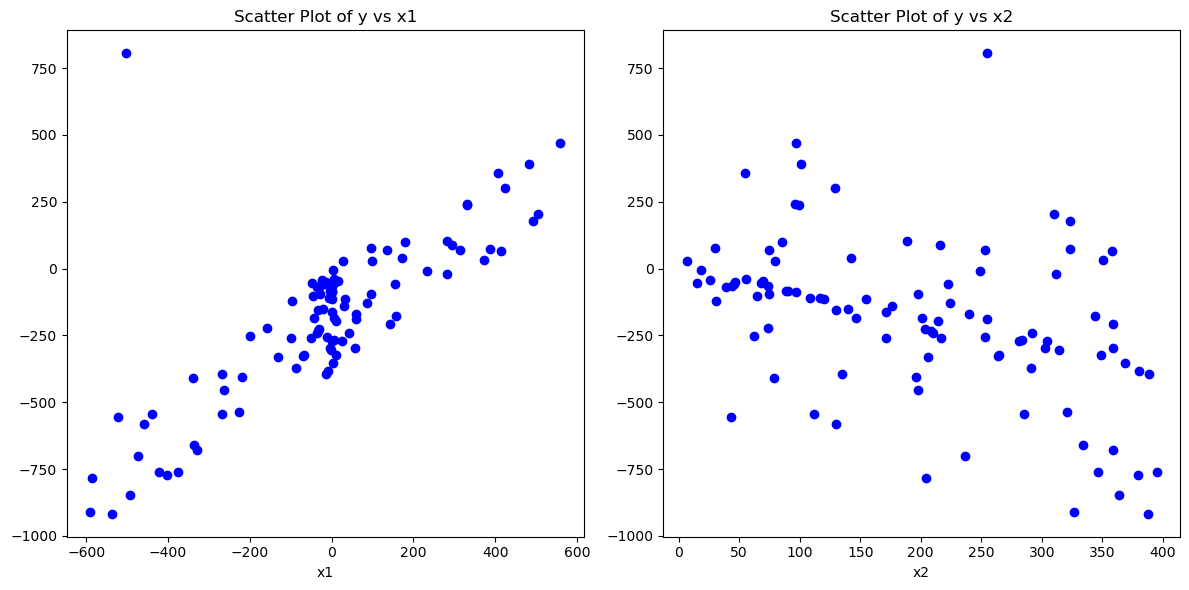

In [3]:
plt.figure(figsize=(12,6))

for i, x in enumerate(['x1', 'x2']):
    plt.subplot(1, 2, i+1)
    plt.scatter(data[x], data['y'], color='blue', label='Data Points')
    plt.xlabel(x)
    plt.title(f'Scatter Plot of y vs {x}')

plt.tight_layout()
plt.show()

Prosty rysnek y(x1) i y(x2) sugerują, że istnieje jakaś liniowa zależność, z tym że w drugim przypadku wariancja raczej większa

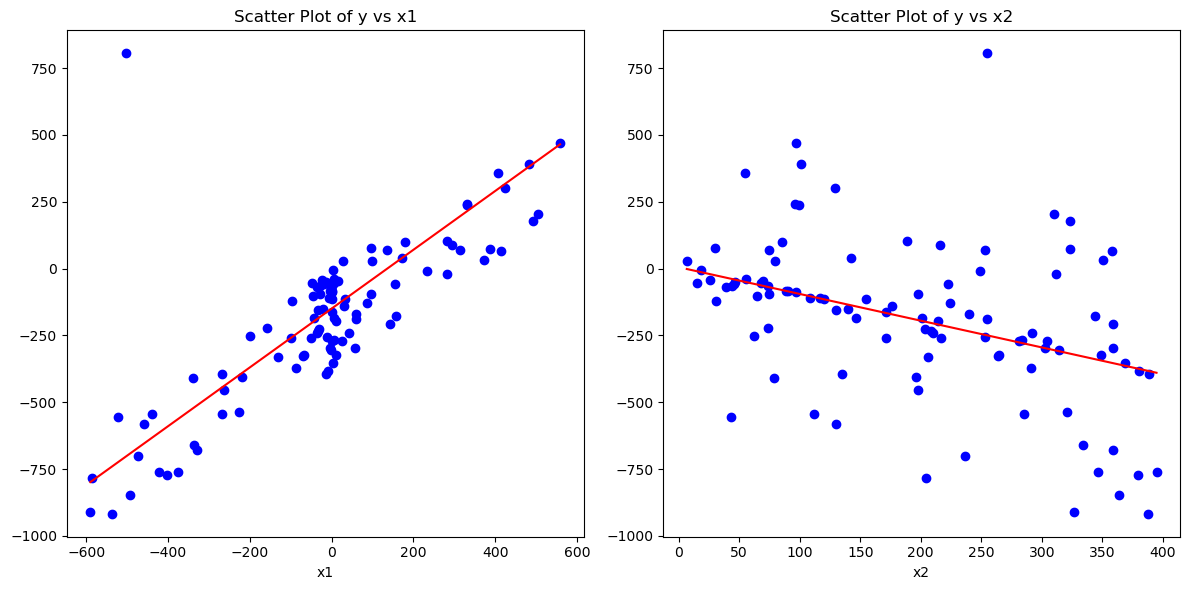

In [4]:
plt.figure(figsize=(12,6))

a = {'x1': 1.1, 'x2': -1.0}
b = {'x1': -150, 'x2': 5.0}

for i, x in enumerate(['x1', 'x2']):
    plt.subplot(1, 2, i+1)
    plt.scatter(data[x], data['y'], color='blue', label='Data Points')
    plt.xlabel(x)
    plt.title(f'Scatter Plot of y vs {x}')

    x_linia = np.array([data[x].min(), data[x].max()])
    y_linia = a[x] * x_linia + b[x]

    plt.plot(x_linia, y_linia, color='red', label=f'Linia: y = {a[x]}*x + {b[x]}')

plt.tight_layout()
plt.show()

Tutaj przykładowej naniesienie prostych na dane.

Teraz trzeba przygotować dane do modelowania. Regresja liniowa zdaje się być odpowiednia.

In [5]:
from sklearn.preprocessing import StandardScaler

def preprocess_data(X_train, y_train, scale=True):

    percent = 0.05 # tyle procent outlierów usuwamy

    n_remove = int(len(X_train) * percent)
    
    indices_sorted = np.argsort(np.abs(y_train))[::-1]

    outlier_indices = indices_sorted[:n_remove]

    mask = np.ones(len(y_train), dtype=bool)
    mask[outlier_indices] = False

    X_train_clean = X_train[mask]
    y_train_clean = y_train[mask]

    if scale:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_clean)
        return X_train_scaled, y_train_clean, scaler
    return X_train_clean, y_train_clean, None

In [6]:
X_scaled, y_scaled, scaler = preprocess_data(data[['x1', 'x2']], data['y'])

In [7]:
print(f"Średnia (x1, x2): {scaler.mean_}")
print(f"Odchylenie standardowe (x1, x2): {scaler.scale_}")

Średnia (x1, x2): [ 11.10058156 188.86317131]
Odchylenie standardowe (x1, x2): [225.27274739 112.39883486]


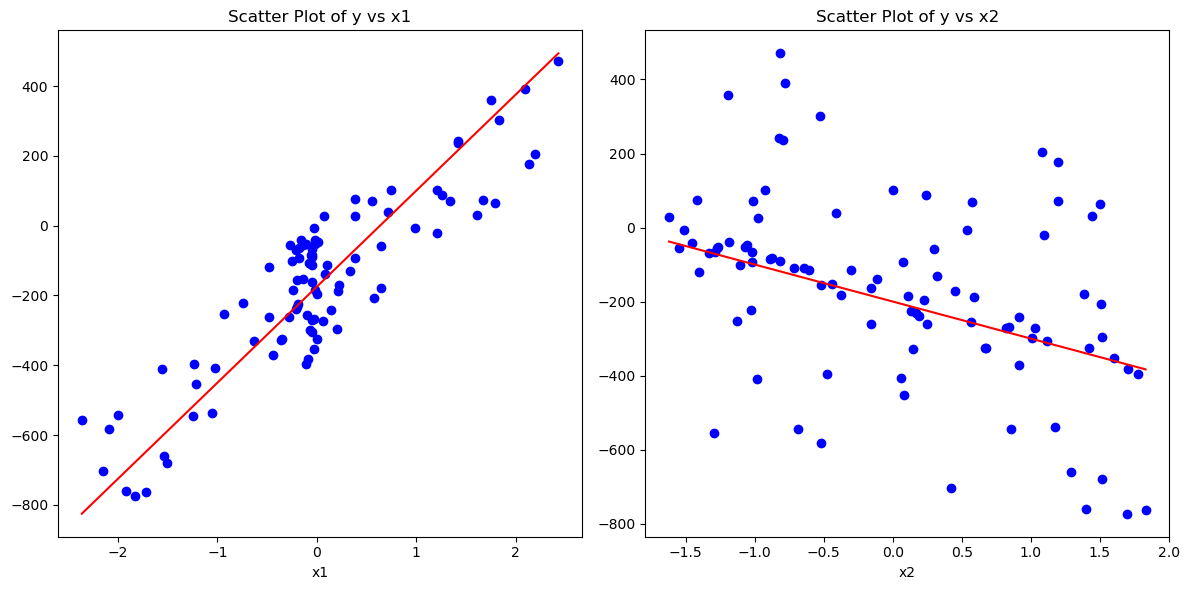

In [8]:
plt.figure(figsize=(12,6))

a = {'x1': 275, 'x2': -100.0}
b = {'x1': -175, 'x2': -200.0}

for i, x in enumerate(['x1', 'x2']):
    plt.subplot(1, 2, i+1)
    plt.scatter(X_scaled[:, i], y_scaled, color='blue', label='Data Points')
    plt.xlabel(x)
    plt.title(f'Scatter Plot of y vs {x}')

    x_linia = np.array([X_scaled[:, i].min(), X_scaled[:, i].max()])
    y_linia = a[x] * x_linia + b[x]

    plt.plot(x_linia, y_linia, color='red', label=f'Linia: y = {a[x]}*x + {b[x]}')

plt.tight_layout()
plt.show()